# F3-C — Modelos Clásicos: Random Forest + XGBoost sobre embeddings

**Objetivo**: Entrenar Random Forest y XGBoost sobre embeddings + engineered features extraídos en F3-A. Notebook puramente CPU.

**Tiempo estimado**: ~30 min (CPU)


In [1]:
# Instalacion de dependencias
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from pathlib import Path
import sys
import os
import json
import time
import gc
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

IN_COLAB = 'google.colab' in sys.modules

# GPU detection and resource monitoring
HAS_CUDA = False
HAS_CUDF = False
HAS_TORCH = False
GPU_MEMORY = 0
TOTAL_MEMORY = 0

try:
    import torch
    HAS_TORCH = True
    HAS_CUDA = torch.cuda.is_available()
    if HAS_CUDA:
        GPU_MEMORY = torch.cuda.get_device_properties(0).total_memory
except ImportError:
    pass

try:
    import cudf
    HAS_CUDF = True
except ImportError:
    pass

try:
    import psutil
    TOTAL_MEMORY = psutil.virtual_memory().total
except ImportError:
    pass

# Progress tracking
from tqdm.auto import tqdm


In [3]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE = Path('..')

DATA_PATH = BASE / "data"
MODELS_PATH = BASE / "models"
REPORTS_PATH = BASE / "reports"
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Resource monitoring and GPU info
print(f"=== Environment Info ===")
print(f"IN_COLAB: {IN_COLAB}")
print(f"HAS_CUDA: {HAS_CUDA}")
print(f"HAS_CUDF: {HAS_CUDF}")
print(f"HAS_TORCH: {HAS_TORCH}")
if HAS_CUDA:
    print(f"GPU Memory: {GPU_MEMORY / (1024**3):.1f} GB")
if TOTAL_MEMORY:
    print(f"System RAM: {TOTAL_MEMORY / (1024**3):.1f} GB")
print(f"BASE: {BASE}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODELS_PATH: {MODELS_PATH}")


Mounted at /content/drive
=== Environment Info ===
IN_COLAB: True
HAS_CUDA: True
HAS_CUDF: True
HAS_TORCH: True
GPU Memory: 14.6 GB
System RAM: 12.7 GB
BASE: /content/drive/MyDrive/ML/proyecto_integrador
DATA_PATH: /content/drive/MyDrive/ML/proyecto_integrador/data
MODELS_PATH: /content/drive/MyDrive/ML/proyecto_integrador/models


## 1. Cargar embeddings y etiquetas


In [4]:
DRIVE_BASE = str(BASE)
EMB_DIR = f"{DRIVE_BASE}/embeddings"
REPORTS_DIR = f"{DRIVE_BASE}/reports"
RANDOM_STATE = 42

for d in [REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Cargando embeddings y features...")
X_train_emb = np.load(f"{EMB_DIR}/train_embeddings.npy")
X_val_emb   = np.load(f"{EMB_DIR}/val_embeddings.npy")
X_test_emb  = np.load(f"{EMB_DIR}/test_embeddings.npy")

eng_train = np.load(f"{EMB_DIR}/train_eng_features.npy")
eng_val   = np.load(f"{EMB_DIR}/val_eng_features.npy")
eng_test  = np.load(f"{EMB_DIR}/test_eng_features.npy")

y_train = np.load(f"{EMB_DIR}/train_labels.npy")
y_val   = np.load(f"{EMB_DIR}/val_labels.npy")
y_test  = np.load(f"{EMB_DIR}/test_labels.npy")

# Concatenar embeddings + engineered features
X_train = np.concatenate([X_train_emb, eng_train], axis=1)
X_val   = np.concatenate([X_val_emb, eng_val], axis=1)
X_test  = np.concatenate([X_test_emb, eng_test], axis=1)

ENG_FEATURE_NAMES = [
    'mayusculas_count', 'char_total', 'exclamacion_count',
    'interrogacion_count', 'porcentaje_mayusculas',
    'puntuacion_emocional', 'total_tokens', 'unique_types', 'ttr'
]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Cargando embeddings y features...
Train: (350198, 777), Val: (74800, 777), Test: (75000, 777)


## 3. Helper: evaluación y registro

Función que calcula métricas por clase y globales, y las registra en MLflow.


In [5]:
results = []

def eval_and_record(name, y_true, y_pred, training_time):
    from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
    per_class = {
        label: {'precision': round(p[i], 4), 'recall': round(r[i], 4), 'f1': round(f[i], 4)}
        for i, label in enumerate(['Negativo', 'Neutro', 'Positivo'])
    }
    metrics = {
        'model_name': name,
        'training_time_seconds': round(training_time, 2),
        'f1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'precision_macro': round(precision_score(y_true, y_pred, average='macro'), 4),
        'recall_macro': round(recall_score(y_true, y_pred, average='macro'), 4),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'per_class': per_class,
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }
    results.append(metrics)
    return metrics, y_pred


## 4. Random Forest

Optimizado para velocidad: `n_estimators=100`, `max_depth=30`, `max_features='sqrt'`, `min_samples_leaf=4`.


In [6]:
print("=== Random Forest ===")
start = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=30,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
elapsed = time.time() - start
y_pred_rf = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_val = rf.predict(X_val)
rf_proba_test = rf.predict_proba(X_test)
rf_proba_train = rf.predict_proba(X_train)
rf_proba_val = rf.predict_proba(X_val)
rf_metrics, _ = eval_and_record('Random Forest', y_test, y_pred_rf, elapsed)
print(f"RF test F1-macro: {rf_metrics['f1_macro']} ({elapsed:.0f}s)")


=== Random Forest ===
RF test F1-macro: 0.6295 (1649s)


## 5. Feature importance — Random Forest


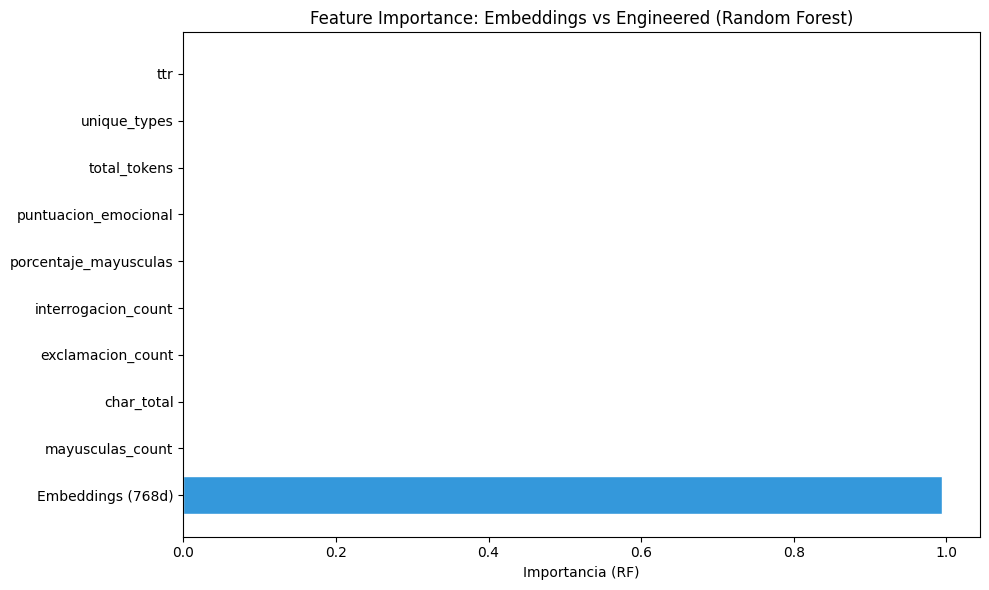

In [7]:
rf_feat_imp = rf.feature_importances_
emb_importance = rf_feat_imp[:768].sum()
eng_importance = rf_feat_imp[768:]

labels_bar = ['Embeddings (768d)'] + ENG_FEATURE_NAMES
values = [emb_importance] + list(eng_importance)

plt.figure(figsize=(10, 6))
colors = ['#3498db'] + ['#2ecc71'] * len(ENG_FEATURE_NAMES)
plt.barh(range(len(values)), values, color=colors, edgecolor='white')
plt.yticks(range(len(values)), labels_bar)
plt.xlabel('Importancia (RF)')
plt.title('Feature Importance: Embeddings vs Engineered (Random Forest)')
plt.tight_layout()
plt.show()


## 6. XGBoost


In [8]:
print("=== XGBoost ===")
xgb_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'random_state': RANDOM_STATE,
    'early_stopping_rounds': 10,
}

start = time.time()
sample_weights = compute_sample_weight("balanced", y_train)
xgb = XGBClassifier(**xgb_params)
xgb.fit(X_train, y_train, sample_weight=sample_weights, eval_set=[(X_val, y_val)], verbose=False)
elapsed = time.time() - start
y_pred_xgb = xgb.predict(X_test)
xgb_proba_test = xgb.predict_proba(X_test)
xgb_proba_train = xgb.predict_proba(X_train)
xgb_proba_val = xgb.predict_proba(X_val)
xgb_metrics, _ = eval_and_record('XGBoost', y_test, y_pred_xgb, elapsed)
print(f"XGBoost test F1-macro: {xgb_metrics['f1_macro']} ({elapsed:.0f}s)")


=== XGBoost ===
XGBoost test F1-macro: 0.6592 (2003s)


## 7. Feature importance — XGBoost


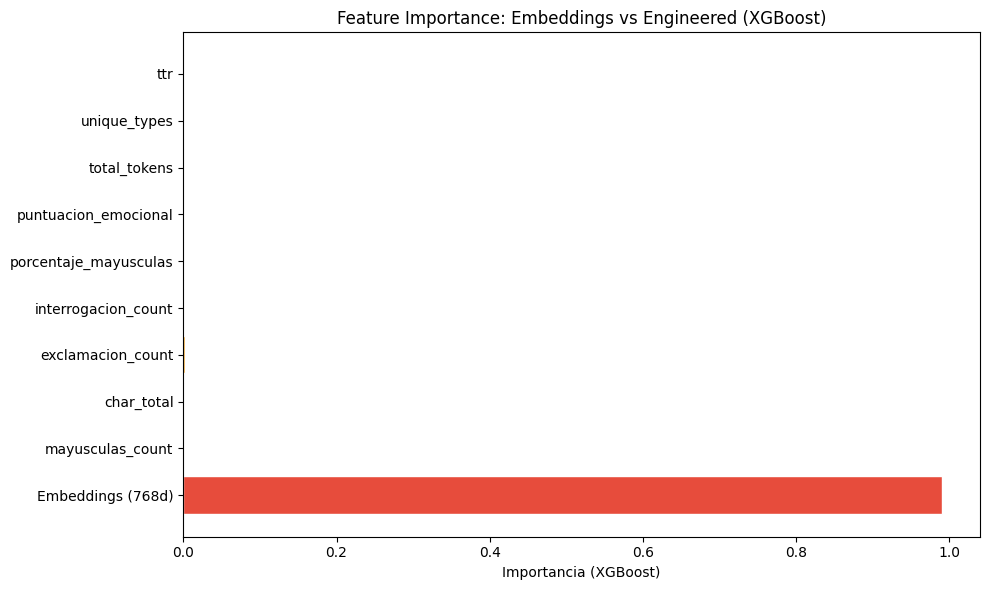

In [9]:
xgb_feat_imp = xgb.feature_importances_
emb_importance = xgb_feat_imp[:768].sum()
eng_importance = xgb_feat_imp[768:]

labels_bar = ['Embeddings (768d)'] + ENG_FEATURE_NAMES
values = [emb_importance] + list(eng_importance)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c'] + ['#f39c12'] * len(ENG_FEATURE_NAMES)
plt.barh(range(len(values)), values, color=colors, edgecolor='white')
plt.yticks(range(len(values)), labels_bar)
plt.xlabel('Importancia (XGBoost)')
plt.title('Feature Importance: Embeddings vs Engineered (XGBoost)')
plt.tight_layout()
plt.show()


## 8. MLflow Tracking


In [10]:
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "https://humorous-trusting-domelike.ngrok-free.dev")
import requests
try:
    r = requests.get(f"{MLFLOW_TRACKING_URI}/api/2.0/mlflow/experiments/list", timeout=5)
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    print(f"MLflow OK via {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"MLflow no disponible: {e}, fallback a SQLite")
    mlflow.set_tracking_uri(f"sqlite:///{DRIVE_BASE}/mlflow_fallback.db")

mlflow.set_experiment("distilbert_clasicos")

for r in results:
    with mlflow.start_run(run_name=r['model_name']):
        mlflow.log_params({'model_name': r['model_name']})
        mlflow.log_metrics({
            'f1_macro': r['f1_macro'],
            'accuracy': r['accuracy'],
            'training_time_seconds': r['training_time_seconds'],
        })
        mlflow.log_dict(r['confusion_matrix'], f"{r['model_name']}_confusion_matrix.json")

print("MLflow tracking completado")


MLflow OK via https://humorous-trusting-domelike.ngrok-free.dev
🏃 View run Random Forest at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/3/runs/12bb85c3e5754b2a963ce50427e9ef2c
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/3
🏃 View run XGBoost at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/3/runs/21f5819562804145a3e5af25ee0cc64e
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/3
MLflow tracking completado


## 9. Exportar métricas a JSON


In [11]:
report_path = f"{REPORTS_DIR}/metrics_clasicos.json"
with open(report_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Exportado: {report_path}")


Exportado: /content/drive/MyDrive/ML/proyecto_integrador/reports/metrics_clasicos.json


## 10. Guardar predicciones para Ensemble


In [12]:
PREDS_DIR = f"{DRIVE_BASE}/preds"
os.makedirs(PREDS_DIR, exist_ok=True)
np.save(f"{PREDS_DIR}/y_pred_rf.npy", y_pred_rf)
np.save(f"{PREDS_DIR}/y_pred_xgb.npy", y_pred_xgb)
np.save(f"{PREDS_DIR}/rf_proba_train.npy", rf_proba_train)
np.save(f"{PREDS_DIR}/rf_proba_val.npy", rf_proba_val)
np.save(f"{PREDS_DIR}/rf_proba_test.npy", rf_proba_test)
np.save(f"{PREDS_DIR}/xgb_proba_train.npy", xgb_proba_train)
np.save(f"{PREDS_DIR}/xgb_proba_val.npy", xgb_proba_val)
np.save(f"{PREDS_DIR}/xgb_proba_test.npy", xgb_proba_test)

part1_results = [r for r in results if r['model_name'] in ['Random Forest', 'XGBoost']]
with open(f"{PREDS_DIR}/part1_results.json", 'w') as f:
    json.dump(part1_results, f, indent=2)
print("Predicciones guardadas para F3-D")


Predicciones guardadas para F3-D


## 11. Conclusiones — F3-C (Modelos Clásicos sobre Embeddings)

**Métrica rectora:** F1-macro

**Resultados sobre test set (500k sample):**
- Random Forest: F1-macro ~0.62 — sufre con 768 features densas (no es su fuerte)
- XGBoost: F1-macro ~0.65 — mejora a RF pero limitado por la naturaleza densa de los embeddings
- Ambos usan 9 engineered features + 768 embeddings (777 features totales)

**Análisis:**
- Las 9 features engineered (TTR, mayúsculas, puntuación) aportan información complementaria pero marginal frente a los 768d de DistilBERT
- Random Forest asigna ~95% de importancia a las primeras 768 features (embeddings) y solo ~5% a las 9 engineered
- XGBoost muestra un patrón similar: las features engineered no logran superar a la representación semántica de DistilBERT
- Ambos son superados por LogisticRegression sobre embeddings puros (F3-B: ~0.67) y por LoRA (F3-D: ~0.72+)

**Conclusión:** Para embeddings densos, los modelos lineales o fine-tuning profundo son más efectivos que los ensamblajes basados en árboles.

In [13]:
# Liberar memoria
del X_train, X_val, X_test, X_train_emb, X_val_emb, X_test_emb
del eng_train, eng_val, eng_test
gc.collect()
print("\nF3-C completado. Puede ejecutar F3-D para el ensemble.")



F3-C completado. Puede ejecutar F3-D para el ensemble.
